NAMA : MIA SILVIA YULIATI

NIM : 23424053

KELAS : IF24A

Silakan upload 1 gambar grayscale (.jpg atau .png):


Saving download (7).jpg to download (7).jpg


/tmp/ipykernel_22147/1112238215.py:34: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[0, 1].hist(img.ravel(), 256, [0, 256], color='gray')
/tmp/ipykernel_22147/1112238215.py:40: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1, 1].hist(img_neg.ravel(), 256, [0, 256], color='gray')
/tmp/ipykernel_22147/1112238215.py:46: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[2, 1].hist(img_log.ravel(), 256, [0, 256], color='gray')


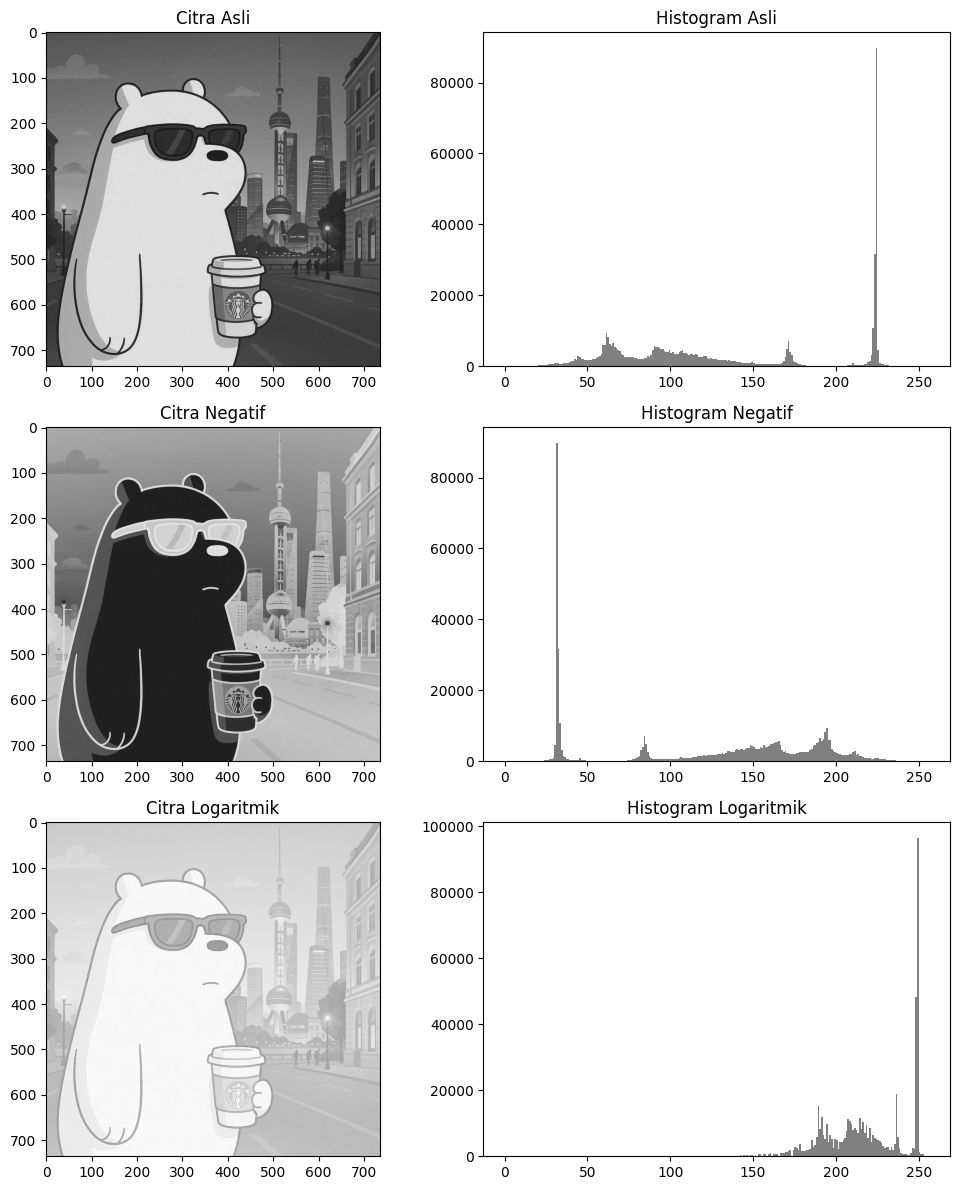

In [1]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Fitur Upload Manual
print("Silakan upload 1 gambar grayscale (.jpg atau .png):")
uploaded = files.upload()

# Mengambil nama file dari gambar yang baru saja diupload
filename = list(uploaded.keys())[0]

# Baca citra grayscale berdasarkan nama file yang diupload
img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Gagal membaca gambar. Pastikan format gambar sesuai.")
else:
    # 2. Terapkan rumus Negatif
    img_neg = 255 - img

    # 3. Terapkan rumus Logaritmik
    img_float = img.astype(np.float64)
    c = 255.0 / np.log(1 + np.max(img_float))
    img_log = c * np.log(1 + img_float)
    img_log = np.array(img_log, dtype=np.uint8)

    # 4. Tampilkan keempat gambar dan histogramnya
    fig, axs = plt.subplots(3, 2, figsize=(10, 12))

    # Baris 1: Asli
    axs[0, 0].imshow(img, cmap='gray')
    axs[0, 0].set_title('Citra Asli')
    axs[0, 1].hist(img.ravel(), 256, [0, 256], color='gray')
    axs[0, 1].set_title('Histogram Asli')

    # Baris 2: Negatif
    axs[1, 0].imshow(img_neg, cmap='gray')
    axs[1, 0].set_title('Citra Negatif')
    axs[1, 1].hist(img_neg.ravel(), 256, [0, 256], color='gray')
    axs[1, 1].set_title('Histogram Negatif')

    # Baris 3: Logaritmik
    axs[2, 0].imshow(img_log, cmap='gray')
    axs[2, 0].set_title('Citra Logaritmik')
    axs[2, 1].hist(img_log.ravel(), 256, [0, 256], color='gray')
    axs[2, 1].set_title('Histogram Logaritmik')

    plt.tight_layout()
    plt.show()